In [1]:
%env JAX_PLATFORM_NAME=cpu
from tqdm.auto import tqdm
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import odds_datasets
from balif import Balif

env: JAX_PLATFORM_NAME=cpu


In [2]:
model_configs = {
    "margin_query": {
        "BALIF": {"model_cls":Balif, "hyperplane_components": 1, "path_score": False},
        #"EBALIF": {"model_cls":Balif, "hyperplane_components": None, "path_score": False},
        # "BALIF (Path)": {"model_cls":Balif, "hyperplane_components": 1, "path_score": True},
        # "EBALIF (Path)": {"model_cls":Balif, "hyperplane_components": None, "path_score": True},
    },
    "cheat_margin_query": {
        "BALIF": {"model_cls":Balif, "hyperplane_components": 1, "path_score": False},
        #"EBALIF": {"model_cls":Balif, "hyperplane_components": None, "path_score": False},
        # "BALIF (Path)": {"model_cls":Balif, "hyperplane_components": 1, "path_score": True},
        # "EBALIF (Path)": {"model_cls":Balif, "hyperplane_components": None, "path_score": True},
    },
    "anom_query": {
        "BALIF": {"model_cls":Balif, "hyperplane_components": 1, "path_score": False},
        #"EBALIF": {"model_cls":Balif, "hyperplane_components": None, "path_score": False},
        # "BALIF (Path)": {"model_cls":Balif, "hyperplane_components": 1, "path_score": True},
        # "EBALIF (Path)": {"model_cls":Balif, "hyperplane_components": None, "path_score": True},
    },
    "random_query": {
        "BALIF": {"model_cls":Balif, "hyperplane_components": 1, "path_score": False},
        #"EBALIF": {"model_cls":Balif, "hyperplane_components": None, "path_score": False},
        # "BALIF (Path)": {"model_cls":Balif, "hyperplane_components": 1, "path_score": True},
        # "EBALIF (Path)": {"model_cls":Balif, "hyperplane_components": None, "path_score": True},
    }
}

  0%|          | 0/17 [00:00<?, ?it/s]

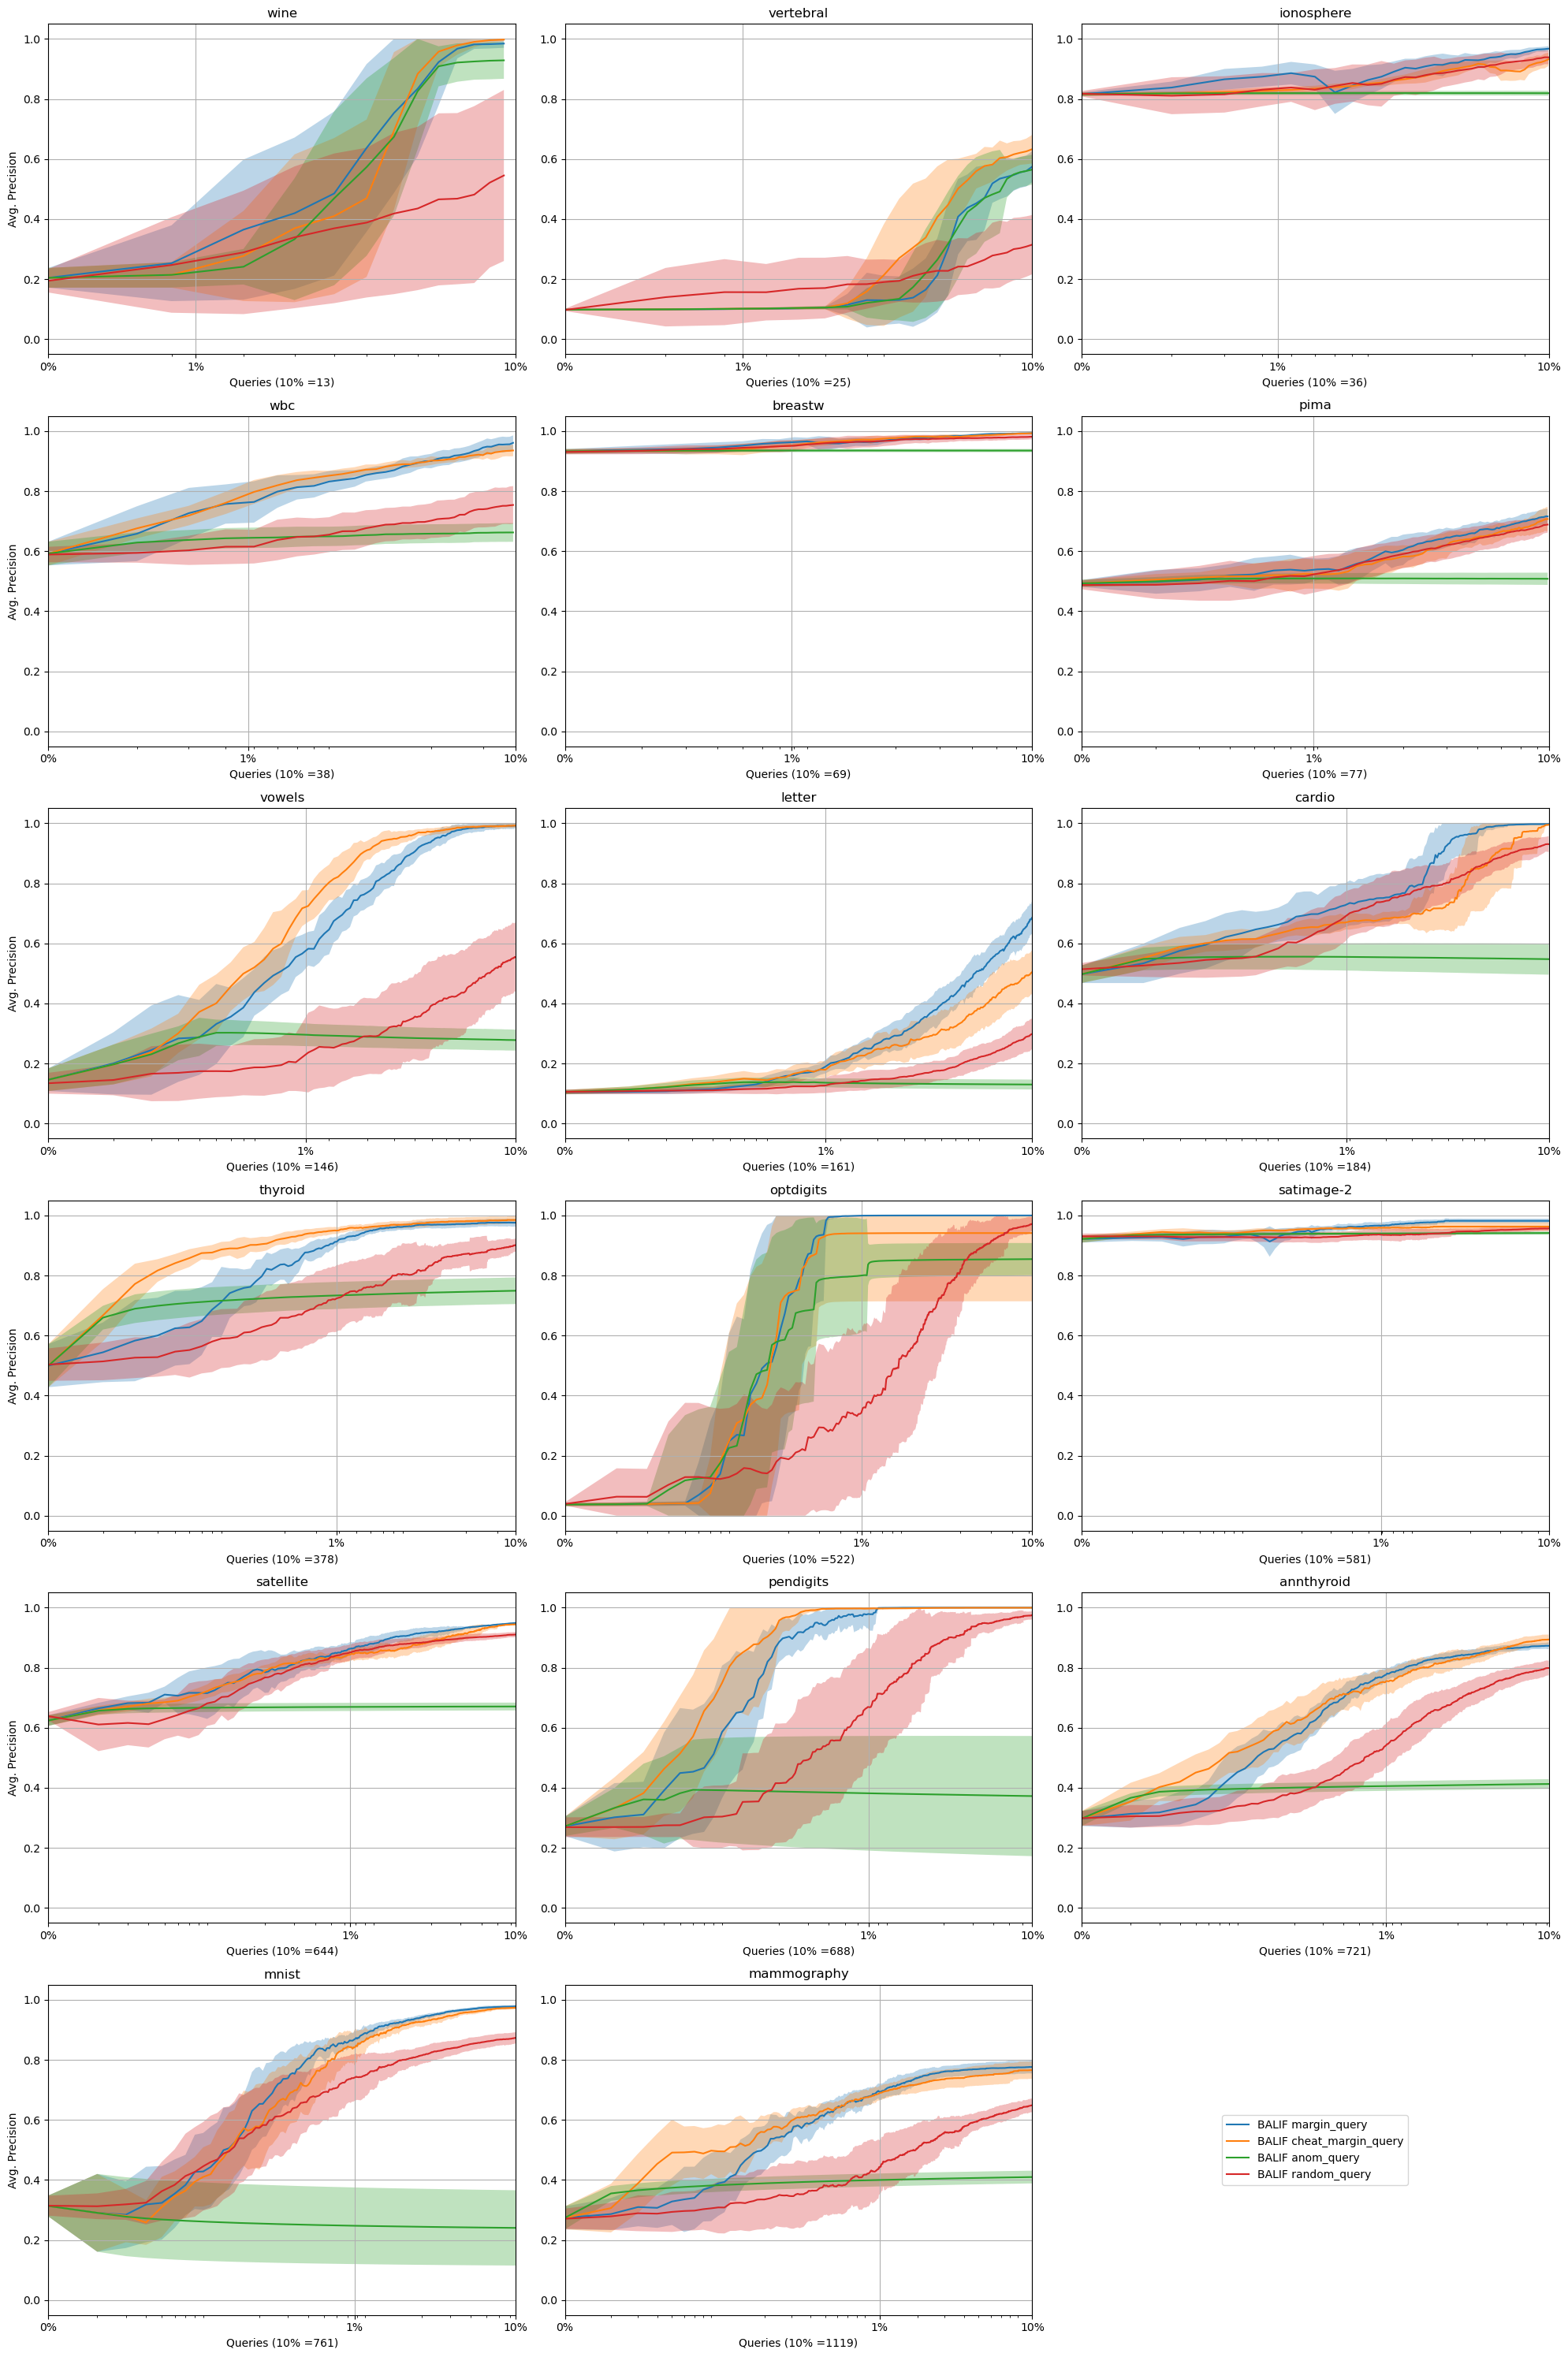

In [3]:
plt.figure(figsize=(20, 30))
plt.subplot(6,3,len(odds_datasets.datasets_names)+1)
for strat, configs in model_configs.items():
    for label in configs.keys():
        plt.plot(0, 0, label=f"{label} {strat}")
plt.title("")
plt.legend(loc="center")
plt.axis("off")

for i, dataset_name in enumerate((pbar := tqdm((odds_datasets.datasets_names)))):
    plt.subplot(6,3,i+1)
    for strat, configs in model_configs.items():
        for label in configs.keys():
            save_path = f"results/{strat}/{dataset_name}_{label}.npy"
            ap = np.load(save_path, allow_pickle=True)
            ap_mean, ap_std = ap.mean(axis=0), ap.std(axis=0)
            plt.semilogx(1 + jnp.arange(len(ap_mean)), ap_mean)
            plt.fill_between(
                1 + jnp.arange(len(ap_mean)),
                jnp.maximum(0, ap_mean - ap_std),
                jnp.minimum(1, ap_mean + ap_std),
                alpha=0.3,
            )
    plt.title(dataset_name)
    data, labels = odds_datasets.load(dataset_name)
    plt.xlabel(f"Queries (10% ={1+len(data)//10})")
    if i % 3 == 0:
        plt.ylabel("Avg. Precision")
    plt.ylim(-0.05, 1.05)
    plt.xlim(1, 1 + data.shape[0] / 10)
    plt.xticks([1, 1 + data.shape[0] / 100, 1 + data.shape[0] / 10], labels=["0%", "1%", "10%"])
    plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    plt.grid()
plt.tight_layout()
plt.savefig(f"figures/ap_evolution/ap_all.pdf", bbox_inches="tight")
plt.show()